# Base Models
El objetivo de este notebook es entrenar modelos base sobre el dataset limpio. De esta manera tenemos una performance baseline con la que podemos comparar más adelante, la cual debemos superar

In [2]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from sklearn.model_selection import train_test_split

from src.utils import print_model_metrics, get_dev_set
from src.constants import TARGET, DevSetType
from src.plots import plot_decision_tree, plot_feature_importance, plot_model_comparison
from src.pipeline import build_base_pipeline
from src.models.base_models import get_dummy_model, get_base_lasso, get_base_tree, get_base_xgboost

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Modelos base _sin_ preprocesamiento
Hacemos un preprocesamiento _muy_ básico para que los modelos puedan funcionar

In [3]:
df = get_dev_set(DevSetType.CLEAN)

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.head()

,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,Cisterna,BusinessCenter,...,ITE_ADD_CITY_NAME,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing
0,59362,39.0,36.0,1.0,1.0,2.0,False,0.0,NaN,False,...,Caseros,Bs.As. G.B.A. Oeste,Caseros,N,-58.566145,-34.599299,6.279294e+03,2022,False,8
1,68287,47.0,40.0,1.0,1.0,2.0,False,7.0,False,False,...,Capital Federal,Capital Federal,Núñez,U,-58.473708,-34.551759,1.092339e+04,2021,False,4
2,59774,128.0,63.0,1.0,1.0,3.0,False,40.0,False,False,...,Capital Federal,Capital Federal,NaN,U,-58.385136,-34.599685,1.081992e+04,2021,False,9
3,62402,436.0,436.0,2.0,3.0,8.0,NaN,50.0,NaN,NaN,...,Capital Federal,Capital Federal,Recoleta,U,-58.393617,-34.585162,1.230069e+05,2022,NaN,11
4,57804,300.0,300.0,2.0,4.0,6.0,False,0.0,False,False,...,Capital Federal,Capital Federal,Monserrat,U,-58.376592,-34.610603,7.714647e+06,2021,False,4


### Pipeline Básico
Solo imputación & encoding

In [4]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

# build_base_pipeline construye un pipeline que lo único que hace es imputar por
# la mediana en feautres numéricas, por la moda en features categóricas,
# Y hacer ordinal encoding de las categóricas.
base_preprocessor = build_base_pipeline(numeric_cols, categorical_cols)

Numeric columns: ['id_grid', 'STotalM2', 'SConstrM2', 'Dormitorios', 'Banos', 'Ambientes', 'Antiguedad', 'Cocheras', 'AreaParrillas', 'LONGITUDE', 'LATITUDE', 'year', 'mes_listing']
Categorical columns: ['Amoblado', 'Cisterna', 'BusinessCenter', 'Gimnasio', 'Laundry', 'Calefaccion', 'AireAC', 'Recepcion', 'Estacionamiento', 'Jacuzzi', 'AreaJuegosInfantiles', 'Chimenea', 'Seguridad', 'Pileta', 'EstacionamientoVisitas', 'CanchaTennis', 'ITE_ADD_CITY_NAME', 'ITE_ADD_STATE_NAME', 'ITE_ADD_NEIGHBORHOOD_NAME', 'ITE_TIPO_PROD', 'SUM']


### 1.1 Dummy Regressor
Predice siempre la media

In [5]:
dummy = get_dummy_model()
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print_model_metrics(y_test, y_pred_dummy, "Dummy Regressor")

=== Modelo: Dummy Regressor ===
RMSE: 681152.9130
MAE: 125955.5544
R2: -0.0000
--------------------------------------------------


### 1.2. Lasso Regression
Requiere un pipeline básico para que pueda funcionar

In [6]:
lasso_model = get_base_lasso(base_preprocessor)

lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print_model_metrics(y_test, y_pred_lasso, "Lasso")

=== Modelo: Lasso ===
RMSE: 678784.3884
MAE: 120446.5758
R2: 0.0069
--------------------------------------------------


### 1.3. Decision Tree

=== Modelo: Decision Tree ===
RMSE: 680648.2053
MAE: 118395.7571
R2: 0.0015
--------------------------------------------------


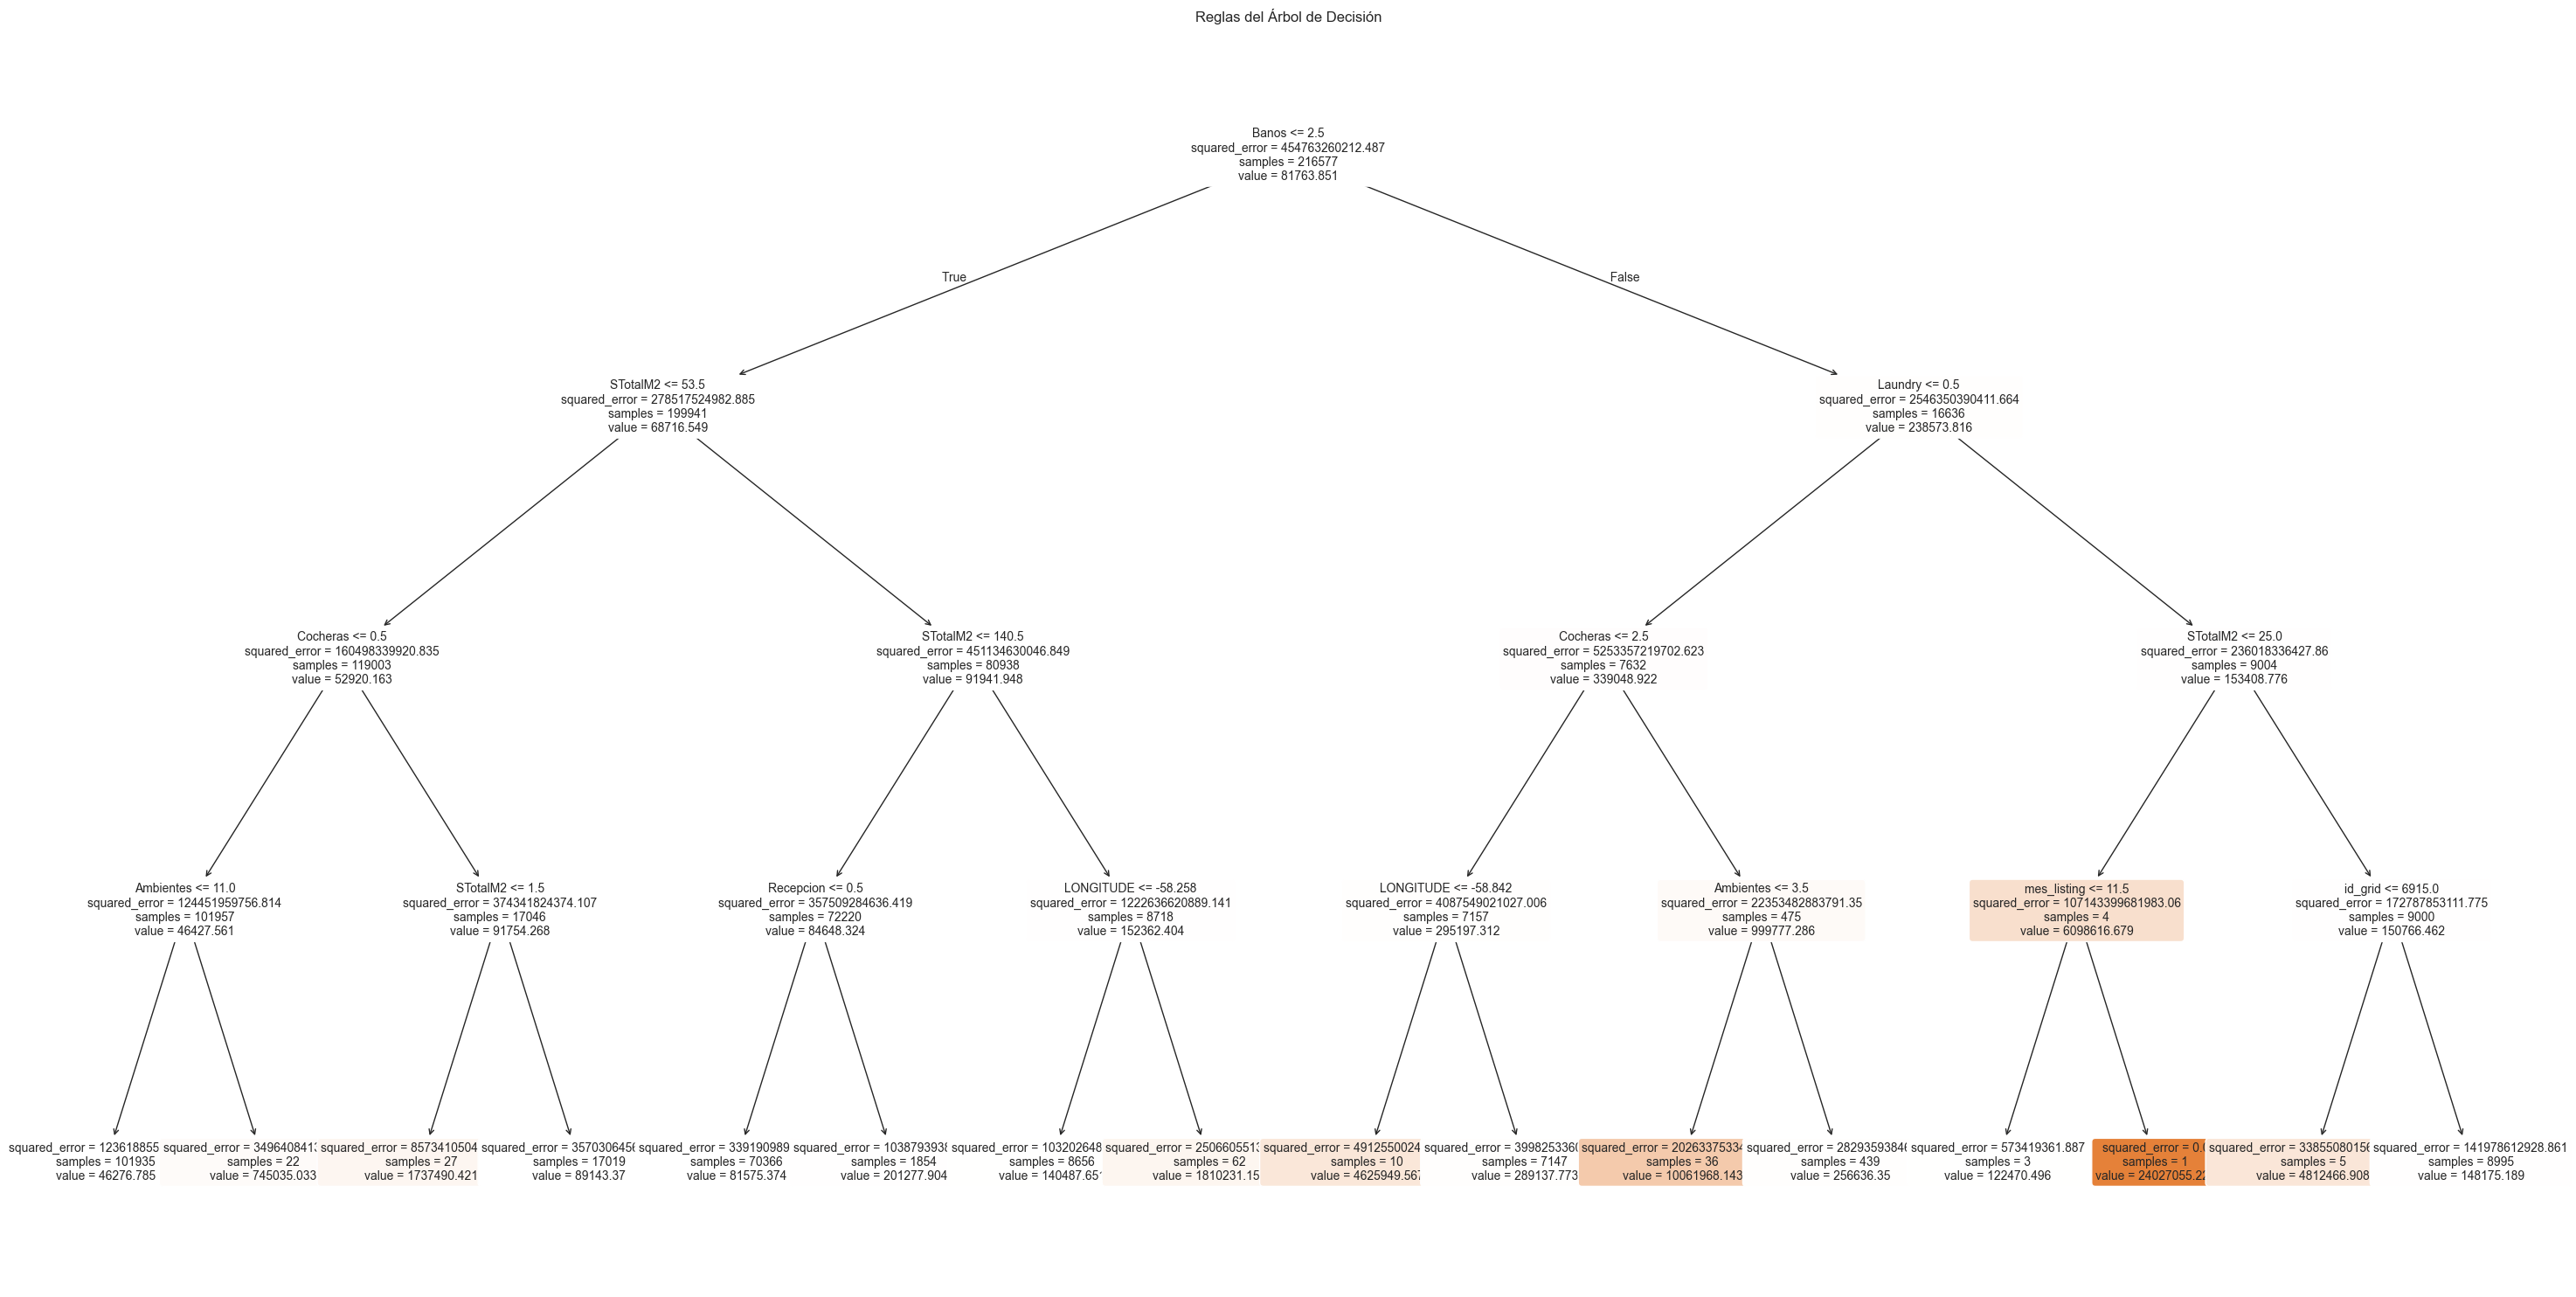

In [7]:
tree_model = get_base_tree(base_preprocessor)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print_model_metrics(y_test, y_pred_tree, "Decision Tree")
plot_decision_tree(tree_model, numeric_cols + categorical_cols, figsize=(30, 15))

### 1.4. XGBoost

In [8]:
xgb_model = get_base_xgboost(base_preprocessor)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print_model_metrics(y_test, y_pred_xgb, "XGBoost")

=== Modelo: XGBoost ===
RMSE: 488988.0037
MAE: 98423.9680
R2: 0.4846
--------------------------------------------------


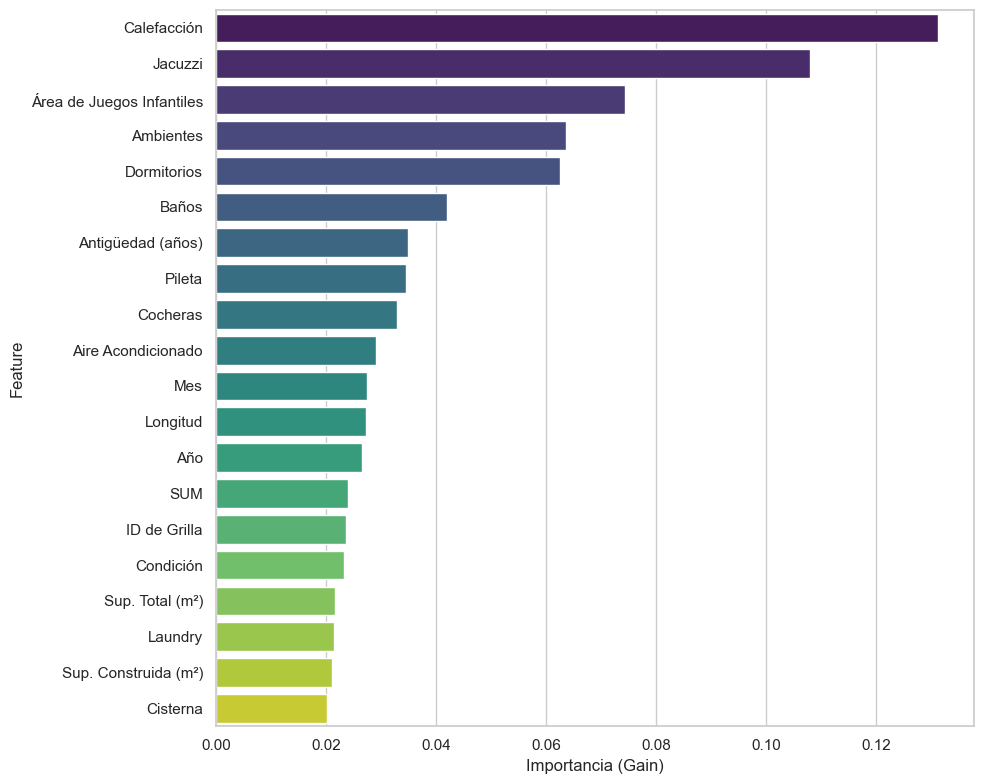

In [9]:
plot_feature_importance(xgb_model, numeric_cols + categorical_cols, filename="01-feature-importance")

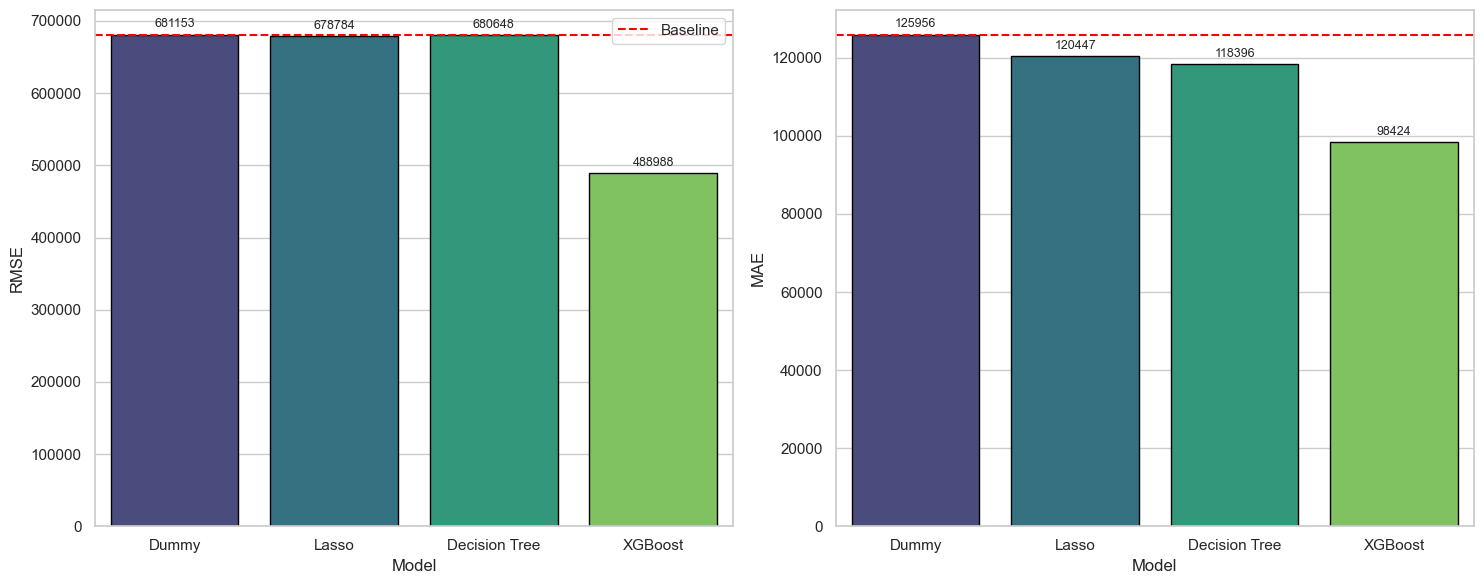

,Model,Variant,RMSE,MAE,R2,MAPE
0,Dummy,Raw,681152.912984,125955.554357,-0.000008,8.174219
1,Lasso,Raw,678784.388450,120446.575791,0.006934,6.576663
2,Decision Tree,Raw,680648.205261,118395.757090,0.001473,6.123546
3,XGBoost,Raw,488988.003662,98423.968044,0.484640,7.164632


In [16]:
models_predictions = {
    'model': ['Dummy', 'Lasso', 'Decision Tree', 'XGBoost'],
    'y_pred': [y_pred_dummy, y_pred_lasso, y_pred_tree, y_pred_xgb],
    'y_test': y_test,
}

plot_model_comparison(models_predictions, filename="02-base-models")

In [ ]:
# Nos guardamos las predicciones
df_base_preds = pd.DataFrame({
    'y_test': y_test,
    'Dummy': y_pred_dummy,
    'Lasso': y_pred_lasso,
    'Decision Tree': y_pred_tree,
    'XGBoost': y_pred_xgb
})
df_base_preds.to_csv('../results/predictions/base_models.csv', index=False)